### Healthcare Readmission Analytics

#### Notebook 07 — Model Interpretation & Business Summary

##### Purpose

This notebook translates data analysis and machine learning results into business recommendations.

The goals are:

- summarize key healthcare insights
- interpret final model performance
- identify major readmission risk factors
- create dashboard-ready output files
- prepare final business recommendations

##### Why This Matters

A machine learning model is only useful if its results can support better decisions.

This notebook connects technical results to healthcare business value.

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Load Required Files

In [2]:
cleaned_df = pd.read_csv("../data/processed/cleaned_healthcare_data.csv")
modeling_df = pd.read_csv("../data/processed/modeling_dataset.csv")

model_comparison = pd.read_csv("../outputs/tuned_model_comparison.csv")
feature_importance = pd.read_csv("../outputs/final_feature_importance.csv")

print("Cleaned data:", cleaned_df.shape)
print("Modeling data:", modeling_df.shape)
print("Model comparison:", model_comparison.shape)
print("Feature importance:", feature_importance.shape)

Cleaned data: (101766, 47)
Modeling data: (101766, 12)
Model comparison: (2, 5)
Feature importance: (11, 2)


Recreate Readmission Flag

In [3]:
cleaned_df["readmitted_flag"] = cleaned_df["readmitted"].apply(
    lambda x: 0 if x == "NO" else 1
)

Executive KPI Summary

In [4]:
executive_kpis = pd.DataFrame({
    "Metric": [
        "Total Encounters",
        "Unique Patients",
        "Overall Readmission Rate (%)",
        "Average Length of Stay",
        "Average Medications",
        "Average Total Utilization"
    ],
    "Value": [
        len(cleaned_df),
        cleaned_df["patient_nbr"].nunique(),
        round(cleaned_df["readmitted_flag"].mean() * 100, 2),
        round(cleaned_df["time_in_hospital"].mean(), 2),
        round(cleaned_df["num_medications"].mean(), 2),
        round(
            cleaned_df["number_outpatient"].mean()
            + cleaned_df["number_emergency"].mean()
            + cleaned_df["number_inpatient"].mean(),
            2
        )
    ]
})

executive_kpis

,Metric,Value
0,Total Encounters,101766.00
1,Unique Patients,71518.00
2,Overall Readmission Rate (%),46.09
3,Average Length of Stay,4.40
4,Average Medications,16.02
5,Average Total Utilization,1.20


Final Model Summary

In [5]:
model_comparison

,model,accuracy,precision,recall,f1_score
0,Baseline Random Forest,0.626019,0.619900,0.487475,0.545769
1,Tuned Random Forest,0.623219,0.600047,0.547276,0.572448


Model Interpretation

The tuned Random Forest model improved recall and F1-score compared to the baseline model.

In healthcare readmission prediction, recall is especially important because it measures how many actual readmitted patients the model successfully identifies.

Final Feature Importance

In [6]:
feature_importance.head(10)

,feature,importance
0,total_utilization,0.207208
1,number_inpatient,0.160779
2,num_lab_procedures,0.135632
3,num_medications,0.112576
4,number_diagnoses,0.088065
5,age_numeric,0.079598
6,time_in_hospital,0.077800
7,num_procedures,0.055056
8,number_emergency,0.039391
9,number_outpatient,0.033108


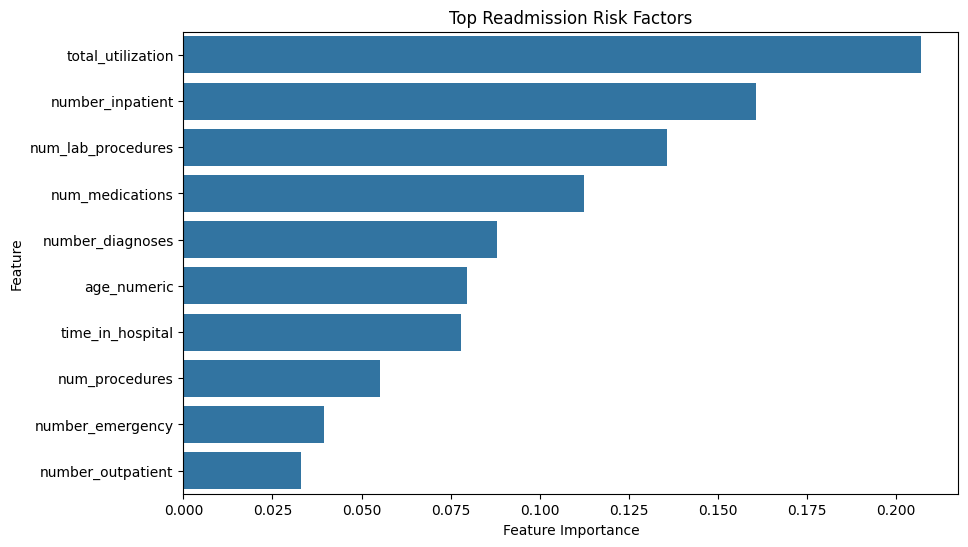

In [7]:
# Chart
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature"
)

plt.title("Top Readmission Risk Factors")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

Create Patient Risk Segments

In [8]:
risk_df = cleaned_df.copy()

risk_df["total_utilization"] = (
    risk_df["number_outpatient"]
    + risk_df["number_emergency"]
    + risk_df["number_inpatient"]
)

risk_df["risk_segment"] = "Low Risk"

risk_df.loc[
    (risk_df["number_inpatient"] >= 1)
    | (risk_df["total_utilization"] >= 2)
    | (risk_df["num_medications"] >= 20),
    "risk_segment"
] = "Moderate Risk"

risk_df.loc[
    (risk_df["number_inpatient"] >= 3)
    | (risk_df["total_utilization"] >= 5)
    | (risk_df["num_medications"] >= 30),
    "risk_segment"
] = "High Risk"

risk_df["risk_segment"].value_counts()

risk_segment
Low Risk         46444
Moderate Risk    39950
High Risk        15372
Name: count, dtype: int64

Risk Segment Summary

In [9]:
risk_summary = (
    risk_df.groupby("risk_segment")
    .agg(
        encounters=("encounter_id", "count"),
        unique_patients=("patient_nbr", "nunique"),
        readmission_rate=("readmitted_flag", "mean"),
        avg_los=("time_in_hospital", "mean"),
        avg_medications=("num_medications", "mean"),
        avg_total_utilization=("total_utilization", "mean")
    )
    .reset_index()
)

risk_summary["readmission_rate"] = (
    risk_summary["readmission_rate"] * 100
).round(2)

risk_summary[[
    "avg_los",
    "avg_medications",
    "avg_total_utilization"
]] = risk_summary[[
    "avg_los",
    "avg_medications",
    "avg_total_utilization"
]].round(2)

risk_summary

,risk_segment,encounters,unique_patients,readmission_rate,avg_los,avg_medications,avg_total_utilization
0,High Risk,15372,10247,61.04,5.90,24.49,4.27
1,Low Risk,46444,44677,36.81,3.57,11.81,0.10
2,Moderate Risk,39950,30667,51.13,4.78,17.66,1.31


Risk Segment Chart

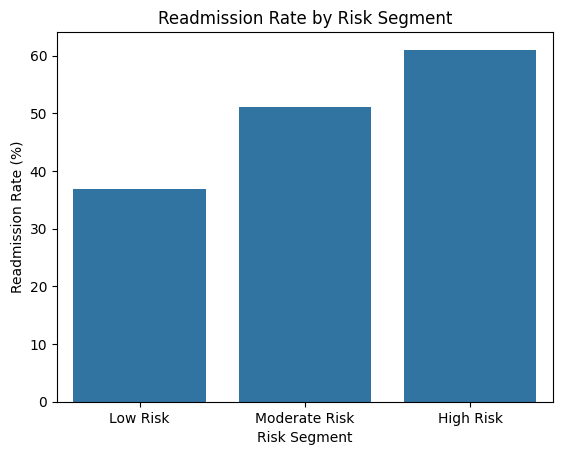

In [10]:
sns.barplot(
    data=risk_summary,
    x="risk_segment",
    y="readmission_rate",
    order=["Low Risk", "Moderate Risk", "High Risk"]
)

plt.title("Readmission Rate by Risk Segment")
plt.ylabel("Readmission Rate (%)")
plt.xlabel("Risk Segment")

plt.show()

#### Business Recommendations
#####
1. Prioritize Patients With Prior Inpatient Visits

Previous inpatient utilization was one of the strongest predictors of readmission.

Patients with prior hospitalizations should be flagged for enhanced discharge planning.

2. Monitor High Utilization Patients

Patients with frequent outpatient, emergency, or inpatient visits show elevated readmission risk.

These patients may benefit from case management or follow-up scheduling.

3. Review Medication Complexity

Higher medication counts were associated with greater readmission risk.

Medication reconciliation and pharmacist-led review may help reduce avoidable readmissions.

4. Focus on Diabetes and Respiratory Diagnoses

Diabetes and respiratory diagnosis groups showed the highest readmission rates.

Targeted disease management programs may improve outcomes for these groups.

5. Use Risk Segmentation for Dashboard Monitoring

Risk segments can help operational teams identify which patient groups require additional support.

Save Dashboard-Ready Files

In [11]:
executive_kpis.to_csv(
    "../outputs/executive_kpis.csv",
    index=False
)

risk_summary.to_csv(
    "../outputs/risk_segment_summary.csv",
    index=False
)

risk_df.to_csv(
    "../data/processed/dashboard_healthcare_data.csv",
    index=False
)

print("Dashboard-ready files saved.")

Dashboard-ready files saved.


#### Final Project Summary
#####
This project analyzed over 100,000 hospital encounters from the UCI Diabetes 130-US Hospitals dataset.

The analysis found that readmission risk is strongly associated with:

- previous inpatient visits
- total healthcare utilization
- medication complexity
- diagnosis burden
- length of stay

The tuned Random Forest model improved recall and F1-score compared to the baseline model, making it more suitable for identifying high-risk patients.

The final outputs are ready for Power BI and Streamlit dashboard development.

In [13]:
import os

print(os.listdir("../outputs"))

['baseline_feature_importance.csv', 'baseline_model_results.csv', 'baseline_predictions.csv', 'diagnosis_readmission_summary.csv', 'executive_kpis.csv', 'final_feature_importance.csv', 'final_model_predictions.csv', 'kpi_summary.csv', 'medication_change_readmission.csv', 'model_feature_list.csv', 'risk_segment_summary.csv', 'tuned_model_comparison.csv']


In [14]:
print(os.listdir("../data/processed"))

['cleaned_healthcare_data.csv', 'dashboard_healthcare_data.csv', 'modeling_dataset.csv']
